In [1]:
import numpy as np
import pandas as pd
import scipy 
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'stackloss')


# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('StackLoss', axis=1),df.StackLoss, test_size=0.1, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              StackLoss   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     46.11
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.67e-07
Time:                        09:28:28   Log-Likelihood:                -45.877
No. Observations:                  18   AIC:                             99.75
Df Residuals:                      14   BIC:                             103.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AirFlow        0.7001      0.152      4.592      0.0

In [2]:

df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'stackloss')


# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('StackLoss', axis=1),df.StackLoss, test_size=0.1, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              StackLoss   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     46.11
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.67e-07
Time:                        09:32:14   Log-Likelihood:                -45.877
No. Observations:                  18   AIC:                             99.75
Df Residuals:                      14   BIC:                             103.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AirFlow        0.7001      0.152      4.592      0.0

# Steps **AirFlow** 
### Step 1: null hypothesis m=0 (coff of m = 0)
### Step 2: P value =0
### Step 3: Decision based on p-value (Reject null hypothesis)
### Step 4: Conclusion (waiting influences eruptions) Effect or not
### Step 5: What is the effect? (when waiting is increased by one unit eruptions will increase by 0.0782 of waiting keeping other factors constant)

## SKLEARN Model Training

In [22]:
from sklearn.linear_model import LinearRegression

df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'stackloss')
x_train, x_test, y_train, y_test = train_test_split(df.drop('StackLoss', axis=1),df.StackLoss, test_size=0.1, random_state=20)

# Creating an instance for the function
regr1 = LinearRegression()

regr1.fit(x_train,y_train)

regr1.intercept_ # Intercept
regr1.coef_ # Coeffecient
regr1.feature_names_in_ # name of features
regr1.score(x_train, y_train) # R2
regr1.predict(x_test) # predict

array([10.83134469, 14.08460126, 10.34327252])

In [23]:
regr1.intercept_ # Intercept


np.float64(-33.28134457561117)

In [24]:
regr1.coef_ # Coeffecient


array([ 0.70013521,  1.34985785, -0.22974125])

In [25]:
regr1.feature_names_in_ # name of features


array(['AirFlow', 'WaterTemp', 'AcidConc'], dtype=object)

In [26]:
regr1.score(x_train, y_train) # R2


0.9080862696530126

In [27]:
regr1.predict(x_test) # predict

array([10.83134469, 14.08460126, 10.34327252])

In [28]:
# 
from sklearn.preprocessing import StandardScaler
scl = StandardScaler()

x_train = scl.fit_transform(x_train)
x_test = scl.transform(x_test)
regr2 = LinearRegression()
regr2.fit(x_train,y_train)

regr2.intercept_   # intercept
regr2.coef_    # coefficients

array([ 6.19332814,  4.40861726, -0.90286981])

In [29]:
x_train

array([[ 0.01884111,  0.20412415, -0.16963779],
       [ 2.05368142,  1.73505523,  0.08481889],
       [-0.43334562, -1.02062073, -1.44192118],
       [-0.43334562, -0.71443451,  1.35710229],
       [-1.33771909, -0.71443451, -2.20529122],
       [-1.33771909, -1.02062073,  0.33927557],
       [ 0.92321458, -0.40824829,  0.84818893],
       [-0.43334562, -1.02062073,  0.33927557],
       [ 0.01884111,  0.51031036, -0.16963779],
       [-0.43334562,  0.51031036, -0.16963779],
       [ 0.01884111,  0.81649658,  1.35710229],
       [ 2.05368142,  1.73505523,  0.33927557],
       [ 1.488448  ,  1.1226828 ,  0.59373225],
       [ 0.01884111,  0.81649658,  1.35710229],
       [-0.43334562, -1.32680694,  0.08481889],
       [-0.43334562, -1.02062073, -1.95083454],
       [-1.33771909, -1.02062073, -0.42409446],
       [ 0.01884111,  0.81649658, -0.16963779]])

In [30]:
print(x_train)

[[ 0.01884111  0.20412415 -0.16963779]
 [ 2.05368142  1.73505523  0.08481889]
 [-0.43334562 -1.02062073 -1.44192118]
 [-0.43334562 -0.71443451  1.35710229]
 [-1.33771909 -0.71443451 -2.20529122]
 [-1.33771909 -1.02062073  0.33927557]
 [ 0.92321458 -0.40824829  0.84818893]
 [-0.43334562 -1.02062073  0.33927557]
 [ 0.01884111  0.51031036 -0.16963779]
 [-0.43334562  0.51031036 -0.16963779]
 [ 0.01884111  0.81649658  1.35710229]
 [ 2.05368142  1.73505523  0.33927557]
 [ 1.488448    1.1226828   0.59373225]
 [ 0.01884111  0.81649658  1.35710229]
 [-0.43334562 -1.32680694  0.08481889]
 [-0.43334562 -1.02062073 -1.95083454]
 [-1.33771909 -1.02062073 -0.42409446]
 [ 0.01884111  0.81649658 -0.16963779]]


In [31]:
df.columns


Index(['AirFlow', 'WaterTemp', 'AcidConc', 'StackLoss'], dtype='object')

In [32]:
import matplotlib.pyplot as plt  # Import matplotlib and assign it the alias 'plt'

plt.hist(x_train.AirFlow)  # Now plt is defined and can be used for plotting

AttributeError: 'numpy.ndarray' object has no attribute 'AirFlow'

(array([3., 0., 6., 0., 5., 0., 1., 0., 1., 2.]),
 array([-1.33771909, -0.99857904, -0.65943899, -0.32029894,  0.01884111,
         0.35798117,  0.69712122,  1.03626127,  1.37540132,  1.71454137,
         2.05368142]),
 <BarContainer object of 10 artists>)

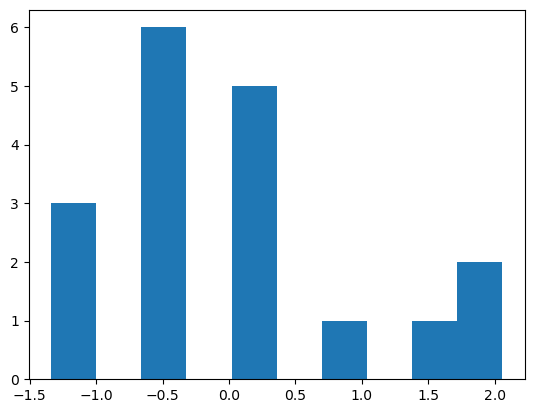

In [33]:
import matplotlib.pyplot as plt  # Import matplotlib and assign it the alias 'plt'

# Option 1: If you know the column index for 'AirFlow' (e.g., it's the first column)
plt.hist(x_train[:, 0])  # Access first column using numerical indexing

# Option 2: If x_train should be a DataFrame, convert it back to DataFrame with column names
# Assuming you have the original DataFrame or know the column names
# x_train_df = pd.DataFrame(x_train, columns=['AirFlow', 'other_columns...'])
# plt.hist(x_train_df.AirFlow)

# Option 3: If you have the original DataFrame before conversion to numpy array
# Use the original DataFrame instead: plt.hist(original_dataframe.AirFlow)

In [34]:
np.mean(x_train.AirFlow)

AttributeError: 'numpy.ndarray' object has no attribute 'AirFlow'

In [35]:
np.std(x_train.AirFlow)

AttributeError: 'numpy.ndarray' object has no attribute 'AirFlow'

- When the values are standardise mean become 0 and and STD become 1, but the distribution of values do not change.

In [39]:
from sklearn.preprocessing import StandardScaler
scl = StandardScaler()
x_train, x_test, y_train, y_test = train_test_split(df.drop('StackLoss', axis=1),df.StackLoss, test_size=0.1, random_state=20)
x_train = scl.fit_transform(x_train)
x_test = scl.transform(x_test)

x_train = pd.DataFrame(x_train,columns=['AirFlow','WaterTemp','AcidConc'])
x_test = pd.DataFrame(x_test,columns=['AirFlow','WaterTemp','AcidConc'])
regr2 = LinearRegression()
regr2.fit(x_train,y_train)

regr2.intercept_   # intercept
regr2.coef_    # coefficients
regr2.feature_names_in_

array(['AirFlow', 'WaterTemp', 'AcidConc'], dtype=object)

In [40]:
df = pd.DataFrame({'Values':[3,6,5,1,6,8,3,8,9,4]})

df['StdScale'] = (df.Values-np.mean(df.Values))/np.std(df.Values,ddof=1)

In [41]:
df.head()

,Values,StdScale
0,3,-0.890045
1,6,0.270883
2,5,-0.116093
3,1,-1.663997
4,6,0.270883


In [42]:
df

,Values,StdScale
0,3,-0.890045
1,6,0.270883
2,5,-0.116093
3,1,-1.663997
4,6,0.270883
5,8,1.044835
6,3,-0.890045
7,8,1.044835
8,9,1.431811
9,4,-0.503069


In [44]:
df['MinMax'] = (df.Values - min(df.Values))/(max(df.Values)-min(df.Values))

In [45]:
df

,Values,StdScale,MinMax
0,3,-0.890045,0.250
1,6,0.270883,0.625
2,5,-0.116093,0.500
3,1,-1.663997,0.000
4,6,0.270883,0.625
5,8,1.044835,0.875
6,3,-0.890045,0.250
7,8,1.044835,0.875
8,9,1.431811,1.000
9,4,-0.503069,0.375


In [46]:
# MinMax Scaller always in O and 1 

In [47]:
# 3 Scallar is Robust.
df['Robust'] = (df.Values - np.median(df.Values))/(np.percentile(df.Values,75) -np.percentile(df.Values,25))

In [48]:
df

,Values,StdScale,MinMax,Robust
0,3,-0.890045,0.250,-0.588235
1,6,0.270883,0.625,0.117647
2,5,-0.116093,0.500,-0.117647
3,1,-1.663997,0.000,-1.058824
4,6,0.270883,0.625,0.117647
5,8,1.044835,0.875,0.588235
6,3,-0.890045,0.250,-0.588235
7,8,1.044835,0.875,0.588235
8,9,1.431811,1.000,0.823529
9,4,-0.503069,0.375,-0.352941


In [49]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

minmax = MinMaxScaler()


In [50]:
df1 = pd.DataFrame({'Values': [3,6,5,1,6,8,3,8,9,4]})

In [52]:
df1.minmax_scaled =  minmax.fit_transform(df1)

/var/folders/1r/zb7wh26j3_56sjck32v92rmh0000gn/T/ipykernel_4100/3326151983.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df1.minmax_scaled =  minmax.fit_transform(df1)


## Categorical/General Regression
Defination :


In [53]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'salaries')

df = df[['yrs_service','gender','salary']]

gender_dum = pd.get_dummies(df.gender,drop_first=True).astype(int)

df = pd.concat([df,gender_dum], axis=1)

df = df.drop('gender', axis=1)


# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('salary', axis=1),df.salary, test_size=0.2, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     21.52
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.75e-09
Time:                        12:10:27   Log-Likelihood:                -3698.4
No. Observations:                 317   AIC:                             7403.
Df Residuals:                     314   BIC:                             7414.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
yrs_service   701.6382    125.946      5.571      

- with respect to female,  if a male is selected then it does not influence the salary
    - gender does not influence salary. 

#### **Day 2: Multiple Linear Regression, Hypothesis Testing, and Data Preprocessing**

1. **Hypothesis Testing Workflow (Airflow vs. Stackloss)**

   * Hypothesis testing is used to check whether a predictor variable has a statistically significant influence on the response variable.

   * In this example, `Airflow` is the predictor variable and `Stackloss` is the response variable.

   * **Null Hypothesis ((H_0)):**

     * The coefficient of `Airflow` is equal to zero.
     * This means that `Airflow` does not significantly influence `Stackloss`.

   * **P-Value:**

     * The calculated P-value of `Airflow` is `0.000`.

   * **Decision:**

     * Since the P-value is less than the significance level of `0.05`, we reject the Null Hypothesis.

   * **Conclusion:**

     * `Airflow` significantly influences `Stackloss`.

   * **Effect Interpretation:**

     * When `Airflow` increases by `1` unit, `Stackloss` changes according to the calculated coefficient, while keeping all other predictor variables constant.

---

2. **Model Training with Scikit-Learn**

   * Scikit-Learn provides a simple and machine-learning-focused workflow for training models.
   * The main steps are:

     1. Instantiate the model.
     2. Fit the model using training data.
     3. Predict the output using testing data.
     4. Evaluate the model performance.

```python
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict the output
y_pred = model.predict(X_test)

# Evaluate the model
score = model.score(X_test, y_test)

print("Model Score:", score)
```

---

3. **Data Scaling and Preprocessing**

   * Data scaling is used to bring numerical features to a similar scale before model training.

   * Scaling is especially important for models that use distance calculations or gradient descent.

   * Examples of algorithms that require scaling:

     * K-Nearest Neighbors
     * K-Means Clustering
     * Support Vector Machine
     * Logistic Regression
     * Neural Networks

---

4. **StandardScaler — Standardization**

   * `StandardScaler` transforms the data so that the mean becomes `0` and the standard deviation becomes `1`.

   * **Formula:**

[
z = \frac{x - \mu}{\sigma}
]

```
- Where:
    - \(x\) is the original value.
    - \(\mu\) is the mean of the feature.
    - \(\sigma\) is the standard deviation.
    - \(z\) is the standardized value.

- **Important Note:**
    - Standardization changes the scale of the data but does not change the original distribution shape.
```

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

---

5. **MinMaxScaler — Normalization**

   * `MinMaxScaler` transforms all values into a fixed range, usually between `0` and `1`.

   * **Formula:**

[
x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}
]

```
- It is useful when:
    - The minimum and maximum values are important.
    - Features must be restricted between `0` and `1`.
    - The dataset does not contain extreme outliers.
```

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

---

6. **RobustScaler**

   * `RobustScaler` is used when the dataset contains outliers.

   * It uses the median and Interquartile Range instead of the mean and standard deviation.

   * **Interquartile Range Formula:**

[
IQR = Q_3 - Q_1
]

```python
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

---

7. **Categorical Variables in Regression**

   * Machine-learning models cannot directly understand text-based categorical values.

   * Categorical variables must be converted into numerical values before model training.

   * Common techniques:

     * Dummy Variables
     * One-Hot Encoding

   * Example:

| City   | City_Mumbai | City_Pune |
| ------ | ----------: | --------: |
| Mumbai |           1 |         0 |
| Pune   |           0 |         1 |

```python
import pandas as pd

df_encoded = pd.get_dummies(
    df,
    columns=["City"],
    drop_first=True
)

df_encoded.head()
```

```
- Using `drop_first=True` removes one category and helps avoid the dummy variable trap.
```

---

#### **Core Concepts: Data Splitting and Model Evaluation**

8. **Training Data**

   * Training data is directly provided to the model so that it can learn patterns.
   * `X_train` contains the predictor variables.
   * `y_train` contains the response variable.

```python
model.fit(X_train, y_train)
```

---

9. **Testing Data**

   * Testing data is kept separate from the training process.
   * It is used only after the model has completed training.
   * A common split is `80%` training data and `20%` testing data.

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
```

---

10. **Validation Data**

    * Validation data is used during the model-development process.

    * It helps to compare models, tune hyperparameters, and detect overfitting.

    * **Key Difference:**

      * Validation happens during model training.
      * Testing happens after model training is complete.

    * Common validation techniques:

      * Leave-One-Out Cross-Validation
      * K-Fold Cross-Validation

```python
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print("Cross-Validation Scores:", scores)
print("Average Score:", scores.mean())
```

---

11. **Evaluating Continuous Data — Regression**

    * Regression models predict continuous numerical values.

    * Examples include salary, temperature, sales, house price, and stackloss.

    * If the actual value is `5` and the model predicts `4`, `4.5`, or `4.9`, then `4.9` is the best prediction because it is closest to the actual value.

    * Common regression evaluation metrics:

      * Mean Absolute Error
      * Mean Squared Error
      * Root Mean Squared Error
      * R-Squared

```python
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-Squared:", r2)
```

---

12. **Evaluating Categorical Data — Classification**

    * Classification models predict categories or classes.

    * Examples include spam or not spam, pass or fail, and disease or no disease.

    * If the actual class is `B`, then predicting `A` or `D` is incorrect.

    * In classification, being close to the correct class does not matter.

    * Classification evaluation works as:

      * `1` means the prediction is correct.
      * `0` means the prediction is incorrect.

    * Common classification evaluation metrics:

      * Accuracy
      * Precision
      * Recall
      * F1-Score
      * Confusion Matrix

```python
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
```


## **Sales Data**

In [55]:
df = pd.read_excel('SalesData.xlsx')


region_dum = pd.get_dummies(df['Region'],drop_first=True).astype(int)

df = pd.concat([df,region_dum], axis=1)

df = df.drop('Region', axis=1)


# Split for train-test
x_train, x_test, y_train, y_test = train_test_split(df.drop('Sales', axis=1),df.Sales, test_size=0.2, random_state=20)

# Add constant term
x_train = sm.add_constant(x_train, prepend=False)
x_test = sm.add_constant(x_test, prepend=False)

# Prepare the model
mod1 = sm.OLS(y_train,x_train).fit()

print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     1889.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:48:58   Log-Likelihood:                -5940.0
No. Observations:                1200   AIC:                         1.189e+04
Df Residuals:                    1194   BIC:                         1.192e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Ad_Budget      3.4866      0.037     93.243      0.0